[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/skoc62_labs.ipynb)


# Data Analysis Labs


- Load [synthetic dataset](https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/skpm20_exam_260213.tsv) and analyze the model below:

[![](https://mermaid.ink/img/pako:eNqVU11v2jAU_SuWUSUqBZbE4SNehVSVPUya9tBKe1hTIRMbsAh2dONQGOK_7wYSIOtemkiJfXzPuefa1weaWqkop0sQ-Yr8eE4MwUdqUKnT1pyQM1aU83PQoxHZvtAFeX2YT74tFhhZEAwVkgjntCulevgyn7ydaR_lGvQ6ursj341UucKPceSXAC3mmSquEXobdHOwskzdLBVOLS3s72-Xw66QWwVutq3IxrUWWdeB0G6mdvjHqAKt3Dd11QamH9Lf-N8Gr1WxdYpWlW__6DxZY87Ftu2TXm9SCbVM_w9kbRBNNRlQ_SeeFnlx-0ybZX0sOFHXM1noLOOdRVy9XuHArhXvpGlaj3tSFCsBIPacDMjgVqLyWLNPz4XNGPNSm1ngHd_325Tw8xT2WYpsjC1BKXMhhPMoGAwbDkrdbNNUwFoBeQSw7812kS72mE5VgbICHPYq8esuweX1yymX7wVeSJoUaKTZt3ct3YqH-e5rYqiH10VLyh2UyqMbBRtRTemhkkuoW6mNSijHoUQjCU3METm5ML-t3TQ0sOVyRflCZAXOylxiW0-1wDu2uaBQtSQ82dI4ylkUnEQoP9Ad5UE87o_G43EcDQeMhT7z6B5RNurHo3g0DgM_iuIwPHr0zymr3x9G0WgY-4NREMUsPP4FnsE59g?type=png)](https://mermaid.live/edit#pako:eNqVU11v2jAU_SuWUSUqBZbE4SNehVSVPUya9tBKe1hTIRMbsAh2dONQGOK_7wYSIOtemkiJfXzPuefa1weaWqkop0sQ-Yr8eE4MwUdqUKnT1pyQM1aU83PQoxHZvtAFeX2YT74tFhhZEAwVkgjntCulevgyn7ydaR_lGvQ6ursj341UucKPceSXAC3mmSquEXobdHOwskzdLBVOLS3s72-Xw66QWwVutq3IxrUWWdeB0G6mdvjHqAKt3Dd11QamH9Lf-N8Gr1WxdYpWlW__6DxZY87Ftu2TXm9SCbVM_w9kbRBNNRlQ_SeeFnlx-0ybZX0sOFHXM1noLOOdRVy9XuHArhXvpGlaj3tSFCsBIPacDMjgVqLyWLNPz4XNGPNSm1ngHd_325Tw8xT2WYpsjC1BKXMhhPMoGAwbDkrdbNNUwFoBeQSw7812kS72mE5VgbICHPYq8esuweX1yymX7wVeSJoUaKTZt3ct3YqH-e5rYqiH10VLyh2UyqMbBRtRTemhkkuoW6mNSijHoUQjCU3METm5ML-t3TQ0sOVyRflCZAXOylxiW0-1wDu2uaBQtSQ82dI4ylkUnEQoP9Ad5UE87o_G43EcDQeMhT7z6B5RNurHo3g0DgM_iuIwPHr0zymr3x9G0WgY-4NREMUsPP4FnsE59g)

- Perform descriptive statistics and data transformations
- Perform bivariate analyses and hypothesis testing
- Perform multivariate analysis, multiple regression


## loading dataset

This code initializes a data science environment by importing **NumPy**, **Pandas**, **Matplotlib**, and **SciPy** for comprehensive analysis. It retrieves the "Palmer Penguins" dataset from a remote GitHub URL, specifically using the `sep="\t"` parameter to correctly parse the **Tab-Separated Values** (TSV) format. The script concludes by calling `df.shape`, which verifies the dataset's dimensions by displaying the total count of rows and columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load the dataset
path = "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/skoc62_labs.tsv"
df = pd.read_csv(path, sep="\t")

print(df.shape)

(500, 9)


This command displays the **structure** of the DataFrame by default. It is used to quickly inspect the data structure, verify that the column headers align with the values, and get a "sneak peek" at the formatting and data types within the set. Use the output to prompt [Google Gemini](https://gemini.google.com) to initialize your data analysis, e.g. **prompt:** "im analyzing a dataframe called df with the following structure, generate code to perform ..."

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   participant_id           500 non-null    object 
 1   advert_variant           500 non-null    object 
 2   product_category         483 non-null    object 
 3   trait_openness           469 non-null    float64
 4   trait_conscientiousness  484 non-null    float64
 5   trait_extraversion       473 non-null    float64
 6   trait_agreeableness      469 non-null    float64
 7   trait_neuroticism        475 non-null    float64
 8   advert_attitude          472 non-null    float64
dtypes: float64(6), object(3)
memory usage: 35.3+ KB


# 1. Descriptive statistics


## use subheadings

Add new text cells like this to write a few sentences explaining the analysis in the associated code cell. Feel free to add subheadings, but don't change the main sections of the notebook. Make note of and explain the findings of your analysis. Visualize your data!

Descriptive Statistics for Advert Attitude:
count    472.000000
mean      13.946819
std        2.058864
min        1.776106
25%       12.890047
50%       13.748285
75%       14.851972
max       29.365980
Name: advert_attitude, dtype: float64


<Figure size 640x480 with 0 Axes>

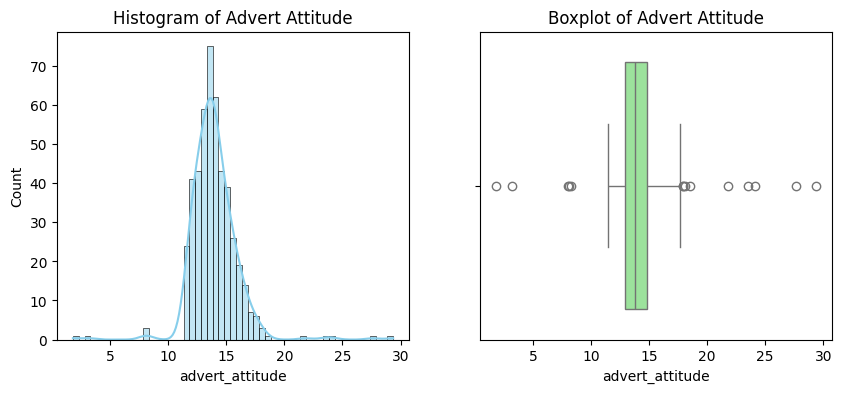

In [23]:
# code cell 1.1, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive Statistics
print("Descriptive Statistics for Advert Attitude:")
print(df['advert_attitude'].describe())

# Visualization: Histogram and Boxplot
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['advert_attitude'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Advert Attitude')
sns.boxplot(x=df['advert_attitude'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Advert Attitude')
plt.savefig('advert_attitude_analysis.png')

Frequency Table for Product Category:
product_category
social_events          103
travel_experiential    101
accessories_tech        96
productivity_apps       94
luxury_fashion          89
NaN                     17
Name: count, dtype: int64


/tmp/ipython-input-373/1044736077.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='product_category', order=order_pc, palette='viridis')


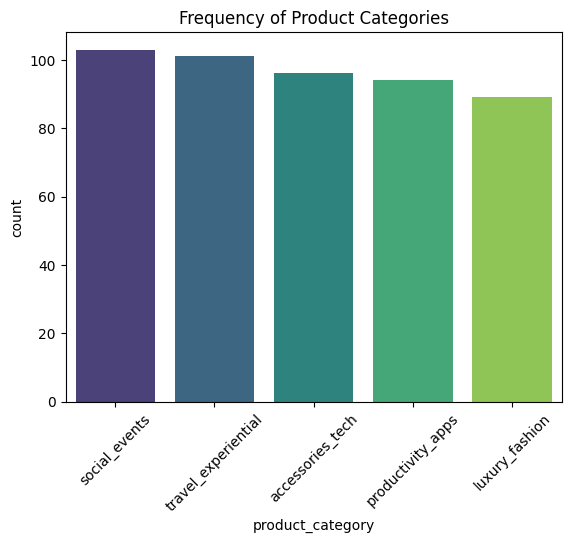

In [24]:
# code cell 1.2, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Frequency Table (including missing values)
print("Frequency Table for Product Category:")
print(df['product_category'].value_counts(dropna=False))

# Visualization: Frequency Bar Chart
plt.clf()
# Sorting categories by frequency for better readability
order_pc = df['product_category'].value_counts().index
sns.countplot(data=df, x='product_category', order=order_pc, palette='viridis')
plt.title('Frequency of Product Categories')
plt.xticks(rotation=45)
plt.savefig('product_category_analysis.png')

Frequency Table for Advert Variant:
advert_variant
treatment    250
control      250
Name: count, dtype: int64


/tmp/ipython-input-373/2951646371.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='advert_variant', order=order_av, palette='magma')


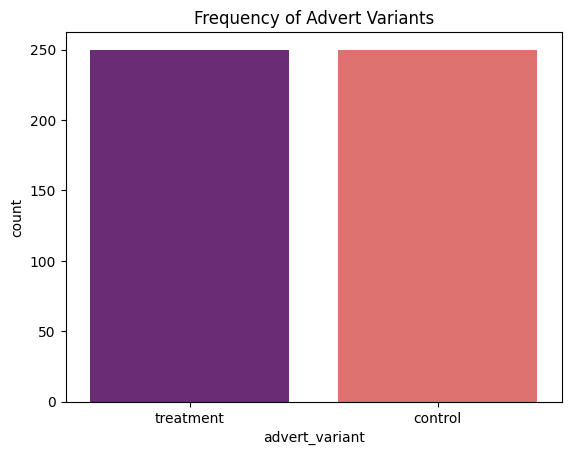

In [25]:
# code cell 1.3, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Frequency Table
print("Frequency Table for Advert Variant:")
print(df['advert_variant'].value_counts())

# Visualization: Frequency Bar Chart
plt.clf()
order_av = df['advert_variant'].value_counts().index
sns.countplot(data=df, x='advert_variant', order=order_av, palette='magma')
plt.title('Frequency of Advert Variants')
plt.savefig('advert_variant_analysis.png')

Descriptive Statistics for Trait Extraversion:
count    473.000000
mean       3.487451
std        0.356879
min        2.333333
25%        3.291667
50%        3.520833
75%        3.708333
max        4.416667
Name: trait_extraversion, dtype: float64


<Figure size 640x480 with 0 Axes>

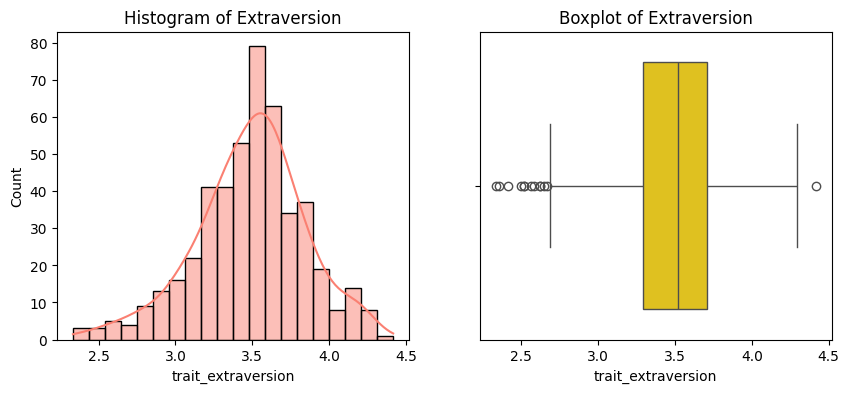

In [26]:
# code cell 1.4, keep this comment, edit content but do not add more code cells
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive Statistics
print("Descriptive Statistics for Trait Extraversion:")
print(df['trait_extraversion'].describe())

# Visualization: Histogram and Boxplot
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['trait_extraversion'].dropna(), kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Histogram of Extraversion')
sns.boxplot(x=df['trait_extraversion'].dropna(), ax=axes[1], color='gold')
axes[1].set_title('Boxplot of Extraversion')
plt.savefig('trait_extraversion_analysis.png')

# 2. Data transformations

In [7]:
# code cell 2.1, keep this comment, edit content but do not add more code cells


In [8]:
# code cell 2.2, keep this comment, edit content but do not add more code cells


In [9]:
# code cell 2.3, keep this comment, edit content but do not add more code cells


In [10]:
# code cell 2.4, keep this comment, edit content but do not add more code cells


# 3. Bivariate analysis


In [11]:
# code cell 3.1, keep this comment, edit content but do not add more code cells


In [12]:
# code cell 3.2, keep this comment, edit content but do not add more code cells


In [13]:
# code cell 3.3, keep this comment, edit content but do not add more code cells


In [14]:
# code cell 3.4, keep this comment, edit content but do not add more code cells


# 4. Hypothesis testing


In [15]:
# code cell 4.1, keep this comment, edit content but do not add more code cells


In [16]:
# code cell 4.2, keep this comment, edit content but do not add more code cells


In [17]:
# code cell 4.3, keep this comment, edit content but do not add more code cells


In [18]:
# code cell 4.4, keep this comment, edit content but do not add more code cells


# 5. Multivariate analysis


In [19]:
# code cell 5.1, keep this comment, edit content but do not add more code cells


In [20]:
# code cell 5.2, keep this comment, edit content but do not add more code cells


In [21]:
# code cell 5.3, keep this comment, edit content but do not add more code cells


In [22]:
# code cell 5.4, keep this comment, edit content but do not add more code cells
